# VLM Comparison: Pump Impeller Defect Detection

This notebook compares two Vision-Language Models on Pump Images dataset

| Model | Parameters | Quantization |
|---|---|---|
| **Qwen2.5-VL-7B-Instruct** | 7B | 4-bit (bitsandbytes) |
| **Llama-3.2-Vision-11B-Instruct** | 11B | 4-bit (bitsandbytes) |

**Workflow:**
1. Load and run Qwen on all images -> save results -> unload
2. Load and run Llama on all images -> save results -> unload
3. Compare outputs side-by-side

**Hardware target:** NVIDIA L4 (24 GB VRAM) / G4 GPU

**Prerequisites:**
- Download thermal images from the Mendeley dataset (link above)
- Accept the Llama-3.2-Vision license at https://huggingface.co/meta-llama/Llama-3.2-11B-Vision-Instruct
- Have a HuggingFace access token ready

## GPU Check

In [ ]:
!nvidia-smi

Tue Apr 21 18:06:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Install Dependencies

In [ ]:
!pip install -q transformers accelerate torch qwen-vl-utils bitsandbytes pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 91.0 MB/s eta 0:00:00


## HuggingFace Login

Required for accessing the gated Llama-3.2-Vision model. Make sure you have accepted the license at https://huggingface.co/meta-llama/Llama-3.2-11B-Vision-Instruct first.

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

## Configuration

Verify the paths and filenames below match your downloaded images. One image from each of these 5 fault categories from the Mendeley dataset.

In [ ]:
import os

# Paths to your uploaded folders
DEFECTIVE_FOLDER = "/content/defective_images"
OKAY_FOLDER = "/content/okay_images"

# Build image list from actual files on disk
IMAGES = []
for fname in sorted(os.listdir(DEFECTIVE_FOLDER)):
    if fname.lower().endswith((".jpeg", ".jpg", ".png")):
        IMAGES.append((os.path.join(DEFECTIVE_FOLDER, fname), "Defective impeller"))

for fname in sorted(os.listdir(OKAY_FOLDER)):
    if fname.lower().endswith((".jpeg", ".jpg", ".png")):
        IMAGES.append((os.path.join(OKAY_FOLDER, fname), "OK impeller"))

# Questions tailored to pump impeller casting inspection
QUESTIONS = [
    # Simple binary - can the model tell ok from defective?
    "This is a top-view image of a cast submersible pump impeller. "
    "Is this casting defective or acceptable? Answer in one sentence.",

    # Detailed inspection - what does the model actually see?
    "You are a quality inspector examining this cast submersible pump "
    "impeller. Describe the surface condition, identify any defects "
    "you observe, and state whether this part should be accepted or rejected.",
]

# Quick check
print(f"Total images: {len(IMAGES)}  "
      f"(Defective: {sum(1 for _, l in IMAGES if l == 'Defective impeller')}, "
      f"OK: {sum(1 for _, l in IMAGES if l == 'OK impeller')})\n")

for path, label in IMAGES:
    status = "[OK]" if os.path.isfile(path) else "[MISSING]"
    print(f"{status}  {label:22s}  {os.path.basename(path)}")

Total images: 14  (Defective: 7, OK: 7)

[OK]  Defective impeller      cast_def_0_1055.jpeg
[OK]  Defective impeller      cast_def_0_1123.jpeg
[OK]  Defective impeller      cast_def_0_3993.jpeg
[OK]  Defective impeller      cast_def_0_7264.jpeg
[OK]  Defective impeller      cast_def_0_8112.jpeg
[OK]  Defective impeller      cast_def_0_8687.jpeg
[OK]  Defective impeller      cast_def_0_994.jpeg
[OK]  OK impeller             cast_ok_0_1091.jpeg
[OK]  OK impeller             cast_ok_0_4437.jpeg
[OK]  OK impeller             cast_ok_0_4561.jpeg
[OK]  OK impeller             cast_ok_0_4582.jpeg
[OK]  OK impeller             cast_ok_0_8079.jpeg
[OK]  OK impeller             cast_ok_0_8762.jpeg
[OK]  OK impeller             cast_ok_0_968.jpeg


## Preview Test Images

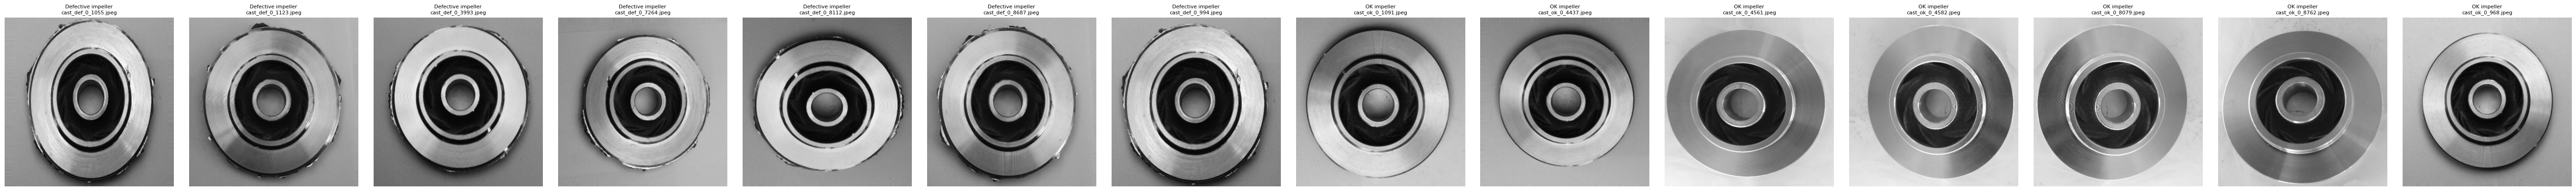

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, len(IMAGES), figsize=(4 * len(IMAGES), 4))
for ax, (img_path, label) in zip(axes, IMAGES):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{label}\n{os.path.basename(img_path)}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Part 1: Qwen2.5-VL-7B-Instruct

### Load Qwen Model (4-bit)

In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info
import torch

QWEN_MODEL_NAME = "Qwen/Qwen2.5-VL-7B-Instruct"

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_NAME)

print("Qwen model loaded (4-bit).")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen model loaded (4-bit).


### Qwen Inference Function

In [ ]:
def ask_qwen(image_path, question):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": question},
            ],
        }
    ]
    text = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = qwen_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to(qwen_model.device)
    output_ids = qwen_model.generate(**inputs, max_new_tokens=512)

    # strip the input tokens so we only get the generated part
    output_ids = [
        out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)
    ]
    return qwen_processor.batch_decode(output_ids, skip_special_tokens=True)[0]

### Run Qwen on All Images

In [ ]:
qwen_results = {}

for img_path, label in IMAGES:
    img_file = os.path.basename(img_path)
    key = f"{label} - {img_file}"
    qwen_results[key] = {}
    print(f"\n{'=' * 60}")
    print(f"Image: {label} ({img_file})")
    print(f"{'=' * 60}")
    for i, q in enumerate(QUESTIONS, 1):
        print(f"\n  Q{i}: {q}")
        response = ask_qwen(img_path, q)
        qwen_results[key][f"Q{i}"] = response
        print(f"  A:  {response}")

print("\nDone with Qwen.")


Image: Defective impeller (cast_def_0_1055.jpeg)

  Q1: This is a top-view image of a cast submersible pump impeller. Is this casting defective or acceptable? Answer in one sentence.
  A:  The image shows a cast submersible pump impeller with a smooth and even surface, indicating it is likely acceptable for use.

  Q2: You are a quality inspector examining this cast submersible pump impeller. Describe the surface condition, identify any defects you observe, and state whether this part should be accepted or rejected.
  A:  The image shows a cast submersible pump impeller. Here's a detailed analysis of its surface condition:

1. **Surface Condition**: The outer edge of the impeller appears to have some roughness and unevenness, which might indicate casting imperfections such as porosity or incomplete filling during the casting process. The inner surface, where the fluid would flow, seems smooth but there is a noticeable dark area that could be indicative of a defect like a cavity or a v

### Save Qwen Results

In [ ]:
import json

QWEN_RESULTS_FILE = "qwen_results.json"

with open(QWEN_RESULTS_FILE, "w") as f:
    json.dump(qwen_results, f, indent=2)

print(f"Saved to {QWEN_RESULTS_FILE}")

Saved to qwen_results.json


### Unload Qwen and Free GPU Memory

In [ ]:
import gc
import torch

del qwen_model
del qwen_processor
gc.collect()
torch.cuda.empty_cache()

print("Qwen unloaded.")
!nvidia-smi

Qwen unloaded.
Tue Apr 21 18:08:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   44C    P0            165W /  600W |     693MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+--------------------------------

---
## Part 2: Llama-3.2-Vision-11B-Instruct

> If `del model` + `torch.cuda.empty_cache()` didn't fully free VRAM above, restart the runtime and re-run from the Configuration cell (Step 3), then skip Part 1 and continue here.

### Load Llama Model (4-bit)

In [ ]:
import torch
from transformers import MllamaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from PIL import Image

LLAMA_MODEL_NAME = "meta-llama/Llama-3.2-11B-Vision-Instruct"

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)

llama_model = MllamaForConditionalGeneration.from_pretrained(
    LLAMA_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)
llama_processor = AutoProcessor.from_pretrained(LLAMA_MODEL_NAME)

print("Llama model loaded (4-bit).")

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/906 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `MllamaImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Llama model loaded (4-bit).


### Llama Inference Function

In [ ]:
def ask_llama(image_path, question):
    image = Image.open(image_path).convert("RGB")
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question},
            ],
        }
    ]
    text = llama_processor.apply_chat_template(
        messages, add_generation_prompt=True
    )
    inputs = llama_processor(
        images=image, text=text, return_tensors="pt"
    ).to(llama_model.device)
    output = llama_model.generate(**inputs, max_new_tokens=512)
    # skip over the input tokens to get just the response
    return llama_processor.decode(
        output[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True
    )

### Run Llama on All Images

In [ ]:
llama_results = {}

for img_path, label in IMAGES:
    img_file = os.path.basename(img_path)
    key = f"{label} - {img_file}"   # unique key per image
    llama_results[key] = {}
    print(f"\n{'=' * 60}")
    print(f"Image: {label} ({img_file})")
    print(f"{'=' * 60}")
    for i, q in enumerate(QUESTIONS, 1):
        print(f"\n  Q{i}: {q}")
        response = ask_llama(img_path, q)
        llama_results[key][f"Q{i}"] = response
        print(f"  A:  {response}")

print("\nDone with Llama.")


Image: Defective impeller (cast_def_0_1055.jpeg)

  Q1: This is a top-view image of a cast submersible pump impeller. Is this casting defective or acceptable? Answer in one sentence.
  A:  The image shows a cast impeller that appears to be in good condition, with no visible defects or damage.

  Q2: You are a quality inspector examining this cast submersible pump impeller. Describe the surface condition, identify any defects you observe, and state whether this part should be accepted or rejected.
  A:  The impeller is a crucial component of a submersible pump, responsible for converting the energy of the motor into kinetic energy of the fluid being pumped. The impeller's surface condition is characterized by:

* **Visual Inspection**: The impeller's surface appears to be clean and free of visible debris or corrosion. There are no signs of rust, corrosion, or other damage that would compromise its functionality.

**Defects Observed**:

* **Minor Scratches**: The impeller has several mi

### Save Llama Results

In [ ]:
import json

LLAMA_RESULTS_FILE = "llama_results.json"

with open(LLAMA_RESULTS_FILE, "w") as f:
    json.dump(llama_results, f, indent=2)

print(f"Saved to {LLAMA_RESULTS_FILE}")

Saved to llama_results.json


### Unload Llama and Free GPU Memory

In [ ]:
import gc
import torch

del llama_model
del llama_processor
gc.collect()
torch.cuda.empty_cache()

print("Llama unloaded.")
!nvidia-smi

Llama unloaded.
Tue Apr 21 18:13:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   47C    P0            188W /  600W |     693MiB /  97887MiB |     35%      Default |
|                                         |                        |             Disabled |
+-------------------------------

---
## Part 3: Side-by-Side Comparison

### Load Saved Results

In [ ]:
import json

with open("qwen_results.json", "r") as f:
    qwen_results = json.load(f)

with open("llama_results.json", "r") as f:
    llama_results = json.load(f)

print(f"Loaded Qwen results for {len(qwen_results)} images.")
print(f"Loaded Llama results for {len(llama_results)} images.")

Loaded Qwen results for 14 images.
Loaded Llama results for 14 images.


### Side-by-Side Output Comparison

In [ ]:
for label in qwen_results:
    print(f"\n{'#' * 70}")
    print(f"  IMAGE: {label}")
    print(f"{'#' * 70}")
    for qkey in sorted(qwen_results[label].keys()):
        q_idx = int(qkey[1:])
        print(f"\n  {qkey}: {QUESTIONS[q_idx - 1]}")
        print(f"  {'~' * 60}")
        print(f"  [Qwen2.5-VL]")
        print(f"  {qwen_results[label][qkey]}")
        print()
        print(f"  [Llama-3.2-Vision]")
        print(f"  {llama_results.get(label, {}).get(qkey, 'N/A')}")
        print()


######################################################################
  IMAGE: Defective impeller - cast_def_0_1055.jpeg
######################################################################

  Q1: This is a top-view image of a cast submersible pump impeller. Is this casting defective or acceptable? Answer in one sentence.
  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  [Qwen2.5-VL]
  The image shows a cast submersible pump impeller with a smooth and even surface, indicating it is likely acceptable for use.

  [Llama-3.2-Vision]
  The image shows a cast impeller that appears to be in good condition, with no visible defects or damage.


  Q2: You are a quality inspector examining this cast submersible pump impeller. Describe the surface condition, identify any defects you observe, and state whether this part should be accepted or rejected.
  ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  [Qwen2.5-VL]
  The image shows a cast submersible pump impeller.

### Scoring Table

Fill in the scores (1-5) and notes for each image x question pair after reviewing the outputs above.

**Scoring rubric:**
- **5** - Excellent: Accurate identification, specific details, actionable advice
- **4** - Good: Mostly correct, minor omissions
- **3** - Adequate: Partially correct, vague or generic
- **2** - Poor: Mostly incorrect or irrelevant
- **1** - Failure: Completely wrong or refused to answer

In [ ]:
import pandas as pd

rows = []
for img_path, label in IMAGES:
    img_file = os.path.basename(img_path)
    key = f"{label} - {img_file}"
    for i in range(1, len(QUESTIONS) + 1):
        rows.append({
            "Image": key,
            "Question": f"Q{i}",
            "Qwen_Score": None,
            "Llama_Score": None,
            "Notes": "",
        })

score_df = pd.DataFrame(rows)
score_df

,Image,Question,Qwen_Score,Llama_Score,Notes
0,Defective impeller - cast_def_0_1055.jpeg,Q1,None,None,
1,Defective impeller - cast_def_0_1055.jpeg,Q2,None,None,
2,Defective impeller - cast_def_0_1123.jpeg,Q1,None,None,
3,Defective impeller - cast_def_0_1123.jpeg,Q2,None,None,
4,Defective impeller - cast_def_0_3993.jpeg,Q1,None,None,
5,Defective impeller - cast_def_0_3993.jpeg,Q2,None,None,
6,Defective impeller - cast_def_0_7264.jpeg,Q1,None,None,
7,Defective impeller - cast_def_0_7264.jpeg,Q2,None,None,
8,Defective impeller - cast_def_0_8112.jpeg,Q1,None,None,
9,Defective impeller - cast_def_0_8112.jpeg,Q2,None,None,


### Record Scores

Uncomment and set scores per row after reviewing the model outputs above.

In [ ]:
# row 0 = Healthy motor, Q1
# score_df.at[0, "Qwen_Score"] = 4
# score_df.at[0, "Llama_Score"] = 3
# score_df.at[0, "Notes"] = "Qwen identified normal operation; Llama was vague"

# ... fill in the rest ...

# score_df

### Summary Statistics

In [ ]:
# needs all scores filled in first
if score_df["Qwen_Score"].notna().all() and score_df["Llama_Score"].notna().all():
    print("=== Average Scores ===")
    print(f"  Qwen2.5-VL-7B:        {score_df['Qwen_Score'].mean():.2f}")
    print(f"  Llama-3.2-Vision-11B:  {score_df['Llama_Score'].mean():.2f}")
    print()

    print("=== Per-Image Average ===")
    per_image = score_df.groupby("Image")[["Qwen_Score", "Llama_Score"]].mean()
    print(per_image.to_string())
    print()

    print("=== Per-Question Average ===")
    per_q = score_df.groupby("Question")[["Qwen_Score", "Llama_Score"]].mean()
    print(per_q.to_string())
else:
    print("Fill in all scores in the table above first.")

Fill in all scores in the table above first.


### Save Scoring Table

In [ ]:
score_df.to_csv("vlm_comparison_scores.csv", index=False)
print("Scores saved to vlm_comparison_scores.csv")

Scores saved to vlm_comparison_scores.csv


---
## Conclusions

- Which model performed better overall?
- Which model was better at fault detection vs. maintenance recommendations?
- Any notable differences in response style or specificity?
- Limitations of this 4-bit quantized comparison?